# import packages

In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import math
from windrose import WindroseAxes

# Loading the data

In [64]:
import pandas as pd

path = "../data/benin-malanville.csv"

# If it's a CSV:
df = pd.read_csv(path)
print("Dataset shape (rows, columns):")
print(df.shape)


Dataset shape (rows, columns):
(525600, 19)


# 1. Summary Statistics & Missing-Value Report

In [42]:
print("An overview of the dataset: the first 5 rows")
df.head()

An overview of the dataset: the first 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-08-09 00:01,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,0.1,122.1,0.0,998,0,0.0,26.3,26.2,NaN
1,2021-08-09 00:02,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,0.0,0.0,0.0,998,0,0.0,26.3,26.2,NaN
2,2021-08-09 00:03,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,0.5,124.6,1.5,997,0,0.0,26.4,26.2,NaN
3,2021-08-09 00:04,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,120.3,1.3,997,0,0.0,26.4,26.3,NaN
4,2021-08-09 00:05,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,113.2,1.0,997,0,0.0,26.4,26.3,NaN


In [43]:
print("An overview of the dataset: the last 5 rows")
df.tail()

An overview of the dataset: the last 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
525595,2022-08-08 23:56,-5.5,-0.1,-5.9,0.0,0.0,23.1,98.3,0.3,1.1,0.5,119.3,4.1,996,0,0.0,23.5,22.9,NaN
525596,2022-08-08 23:57,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.3,0.2,0.7,0.4,115.2,2.3,996,0,0.0,23.5,22.9,NaN
525597,2022-08-08 23:58,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.4,0.6,1.1,0.5,129.8,3.4,996,0,0.0,23.5,22.9,NaN
525598,2022-08-08 23:59,-5.5,-0.1,-5.8,0.0,0.0,23.1,98.3,0.9,1.3,0.5,124.4,4.3,996,0,0.0,23.5,22.9,NaN
525599,2022-08-09 00:00,-5.5,-0.1,-5.7,0.0,0.0,23.1,98.3,1.2,1.6,0.3,124.1,5.9,996,0,0.0,23.5,22.9,NaN


In [44]:
print("An overview of the dataset: a random sample of 5 rows")
df.sample(5)

An overview of the dataset: a random sample of 5 rows


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
371944,2022-04-24 07:05,51.0,0.6,50.2,46.8,45.6,27.9,67.8,3.1,3.6,0.5,221.2,13.2,990,0,0.0,28.5,27.4,NaN
105968,2021-10-21 14:09,817.0,613.8,292.1,837.0,827.0,37.1,47.4,3.2,4.1,0.5,175.7,13.2,993,0,0.0,63.5,61.6,NaN
295749,2022-03-02 09:10,433.5,386.8,230.8,442.7,440.4,27.6,22.4,0.2,0.7,0.4,85.5,3.2,993,0,0.0,53.9,43.6,NaN
98330,2021-10-16 06:51,27.1,15.3,25.9,28.9,29.2,21.7,88.3,0.9,1.1,0.4,309.5,11.0,993,0,0.0,20.6,20.0,NaN
462815,2022-06-26 09:36,379.2,39.4,350.5,349.5,344.7,28.1,74.6,2.8,3.6,0.5,224.0,13.4,997,0,0.0,42.6,36.6,NaN


In [45]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600

In [46]:
print("The description of the numeric columns:")
print(df.describe())

The description of the numeric columns:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000

In [47]:
print("Check for missing values:")
print(df.isna().sum())

Check for missing values:
Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [48]:
null_percentage = df.isna().mean() * 100
print("Percentage of nulls in each column:")
print(null_percentage)
print("*" * 30)

print("Columns with >5% nulls (percent nulls):")
columns_with_over_5 = null_percentage[null_percentage > 5].sort_values(ascending=False)
if columns_with_over_5.empty:
    print("No columns with >5% nulls")
else:
    print("=============================")
    print(columns_with_over_5)
    print("=============================")

Percentage of nulls in each column:
Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64
******************************
Columns with >5% nulls (percent nulls):
Comments    100.0
dtype: float64


In [49]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


## 1.1 Univariate Analysis

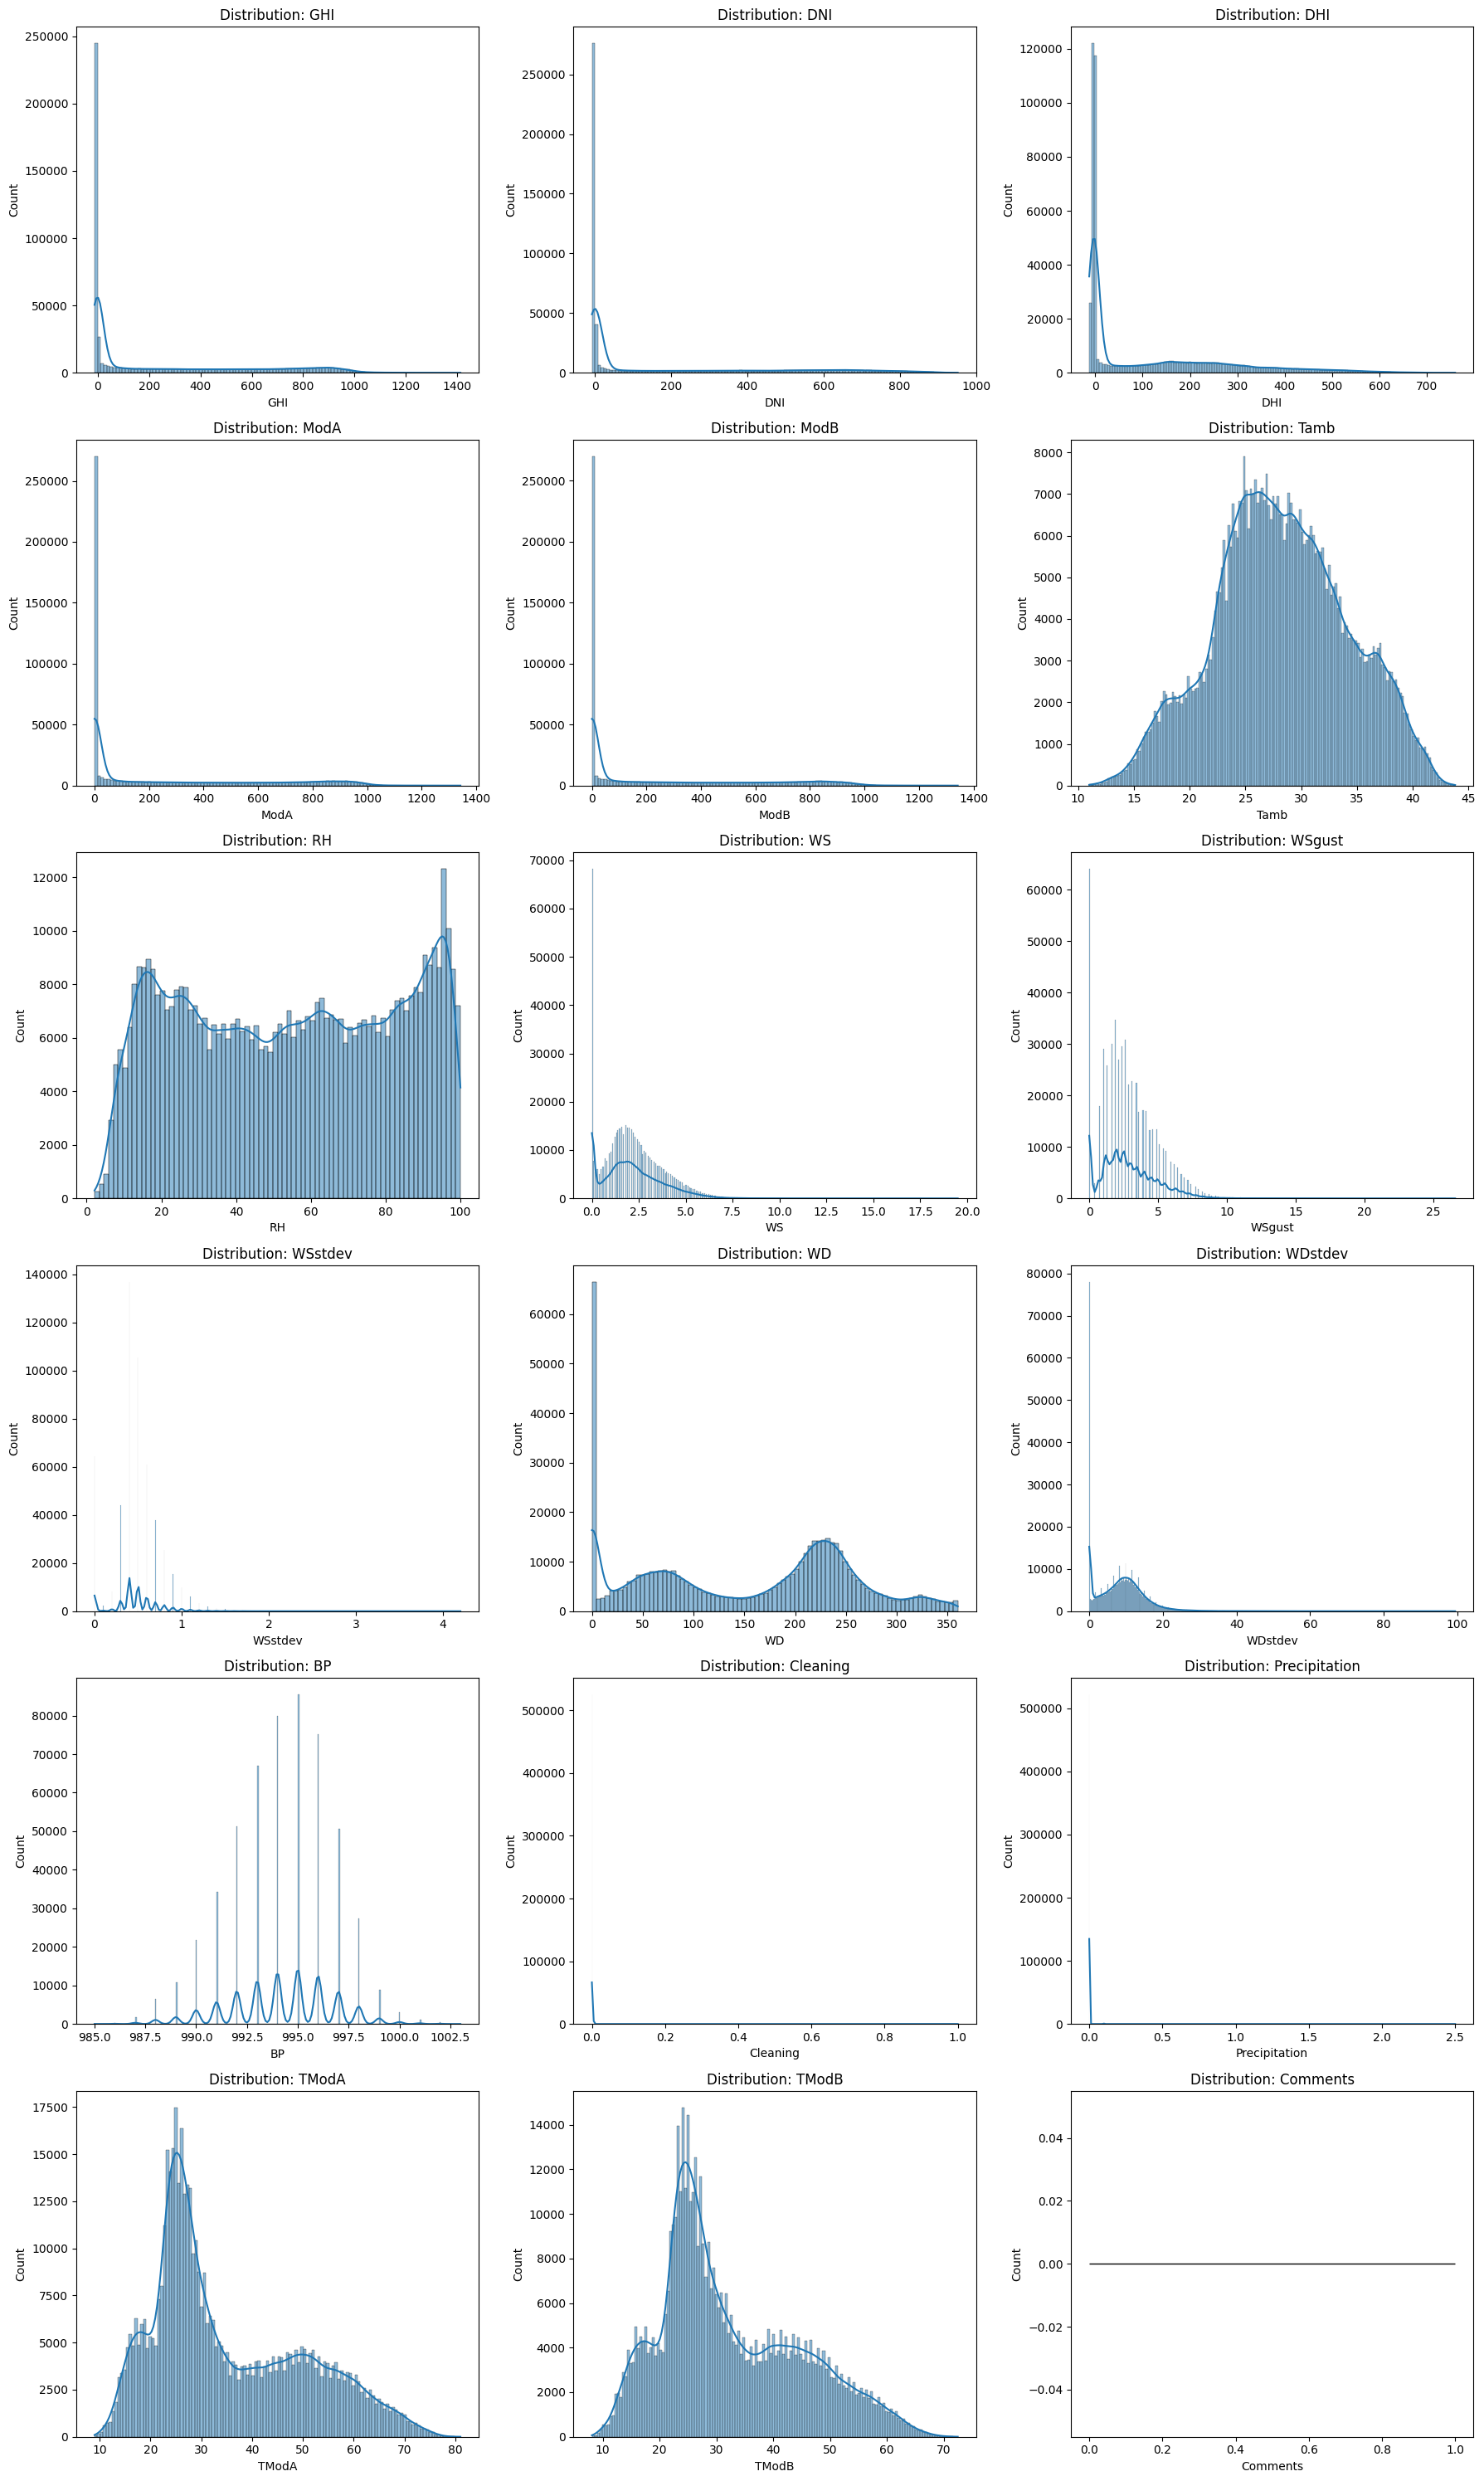

In [33]:
# 1. Get numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Calculate grid dimensions
n_plots = len(num_cols)
# Determine the number of rows needed (3 plots per row)
n_rows = math.ceil(n_plots / 3) 

# 3. Create a single figure with the calculated grid (3 columns wide)
# figsize=(18, ...) ensures the plots are wide enough to be readable
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))

# Flatten the axes array to easily iterate over all subplot locations
axes = axes.flatten()

# 4. Loop and plot each column onto its assigned axis (Histograms: 3 per row)
for i, c in enumerate(num_cols):
    ax = axes[i] # Get the current axis object
    
    # Plot the histogram directly onto the current axis (ax)
    sns.histplot(df[c], kde=True, ax=ax)
    
    ax.set_title(f"Distribution: {c}", fontsize=12)
    ax.set_xlabel(c, fontsize=10)
    ax.set_ylabel("Count", fontsize=10)

# 5. Hide any unused subplots
# This handles cases where n_plots is not a perfect multiple of 3 (e.g., 4, 5, 7, 8 columns)
for j in range(n_plots, n_rows * 3):
    axes[j].axis('off')

plt.tight_layout() # Ensures titles and labels don't overlap
plt.show()

## Univariate Analysis – Interpretation

### Irradiance (GHI, DNI, DHI)
- Many near‑zero readings at night and clear daytime peaks.
- DNI and DHI show more high daytime spikes than GHI.
- Suggestion: treat nighttime rows separately or aggregate to reduce noise.

### Module readings & module temps (ModA, ModB, TModA, TModB)
- Module power is mostly zero at night; module temperatures rise with sunlight.
- Use module power only when irradiance is present (e.g., filter by GHI).

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- Wind speed and gusts are highly variable and show frequent spikes.
- Inspect gust spikes before using raw values; consider capping or event flags.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Ambient temperature and humidity look reasonable.
- Precipitation is mostly zero; consider a binary rain flag if needed.

### Flags, metadata, and quality indicators
- Comments column is empty and can be dropped.
- No exact duplicate rows detected.
- Outlier filtering removed some rows (dataset is smaller after cleaning).

### Overall
- Clear day/night structure dominates the data.
- Main practical issues for a novice to address: handle nighttime zeros and wind/gust spikes before modelling.


## Box Plots (numeric)

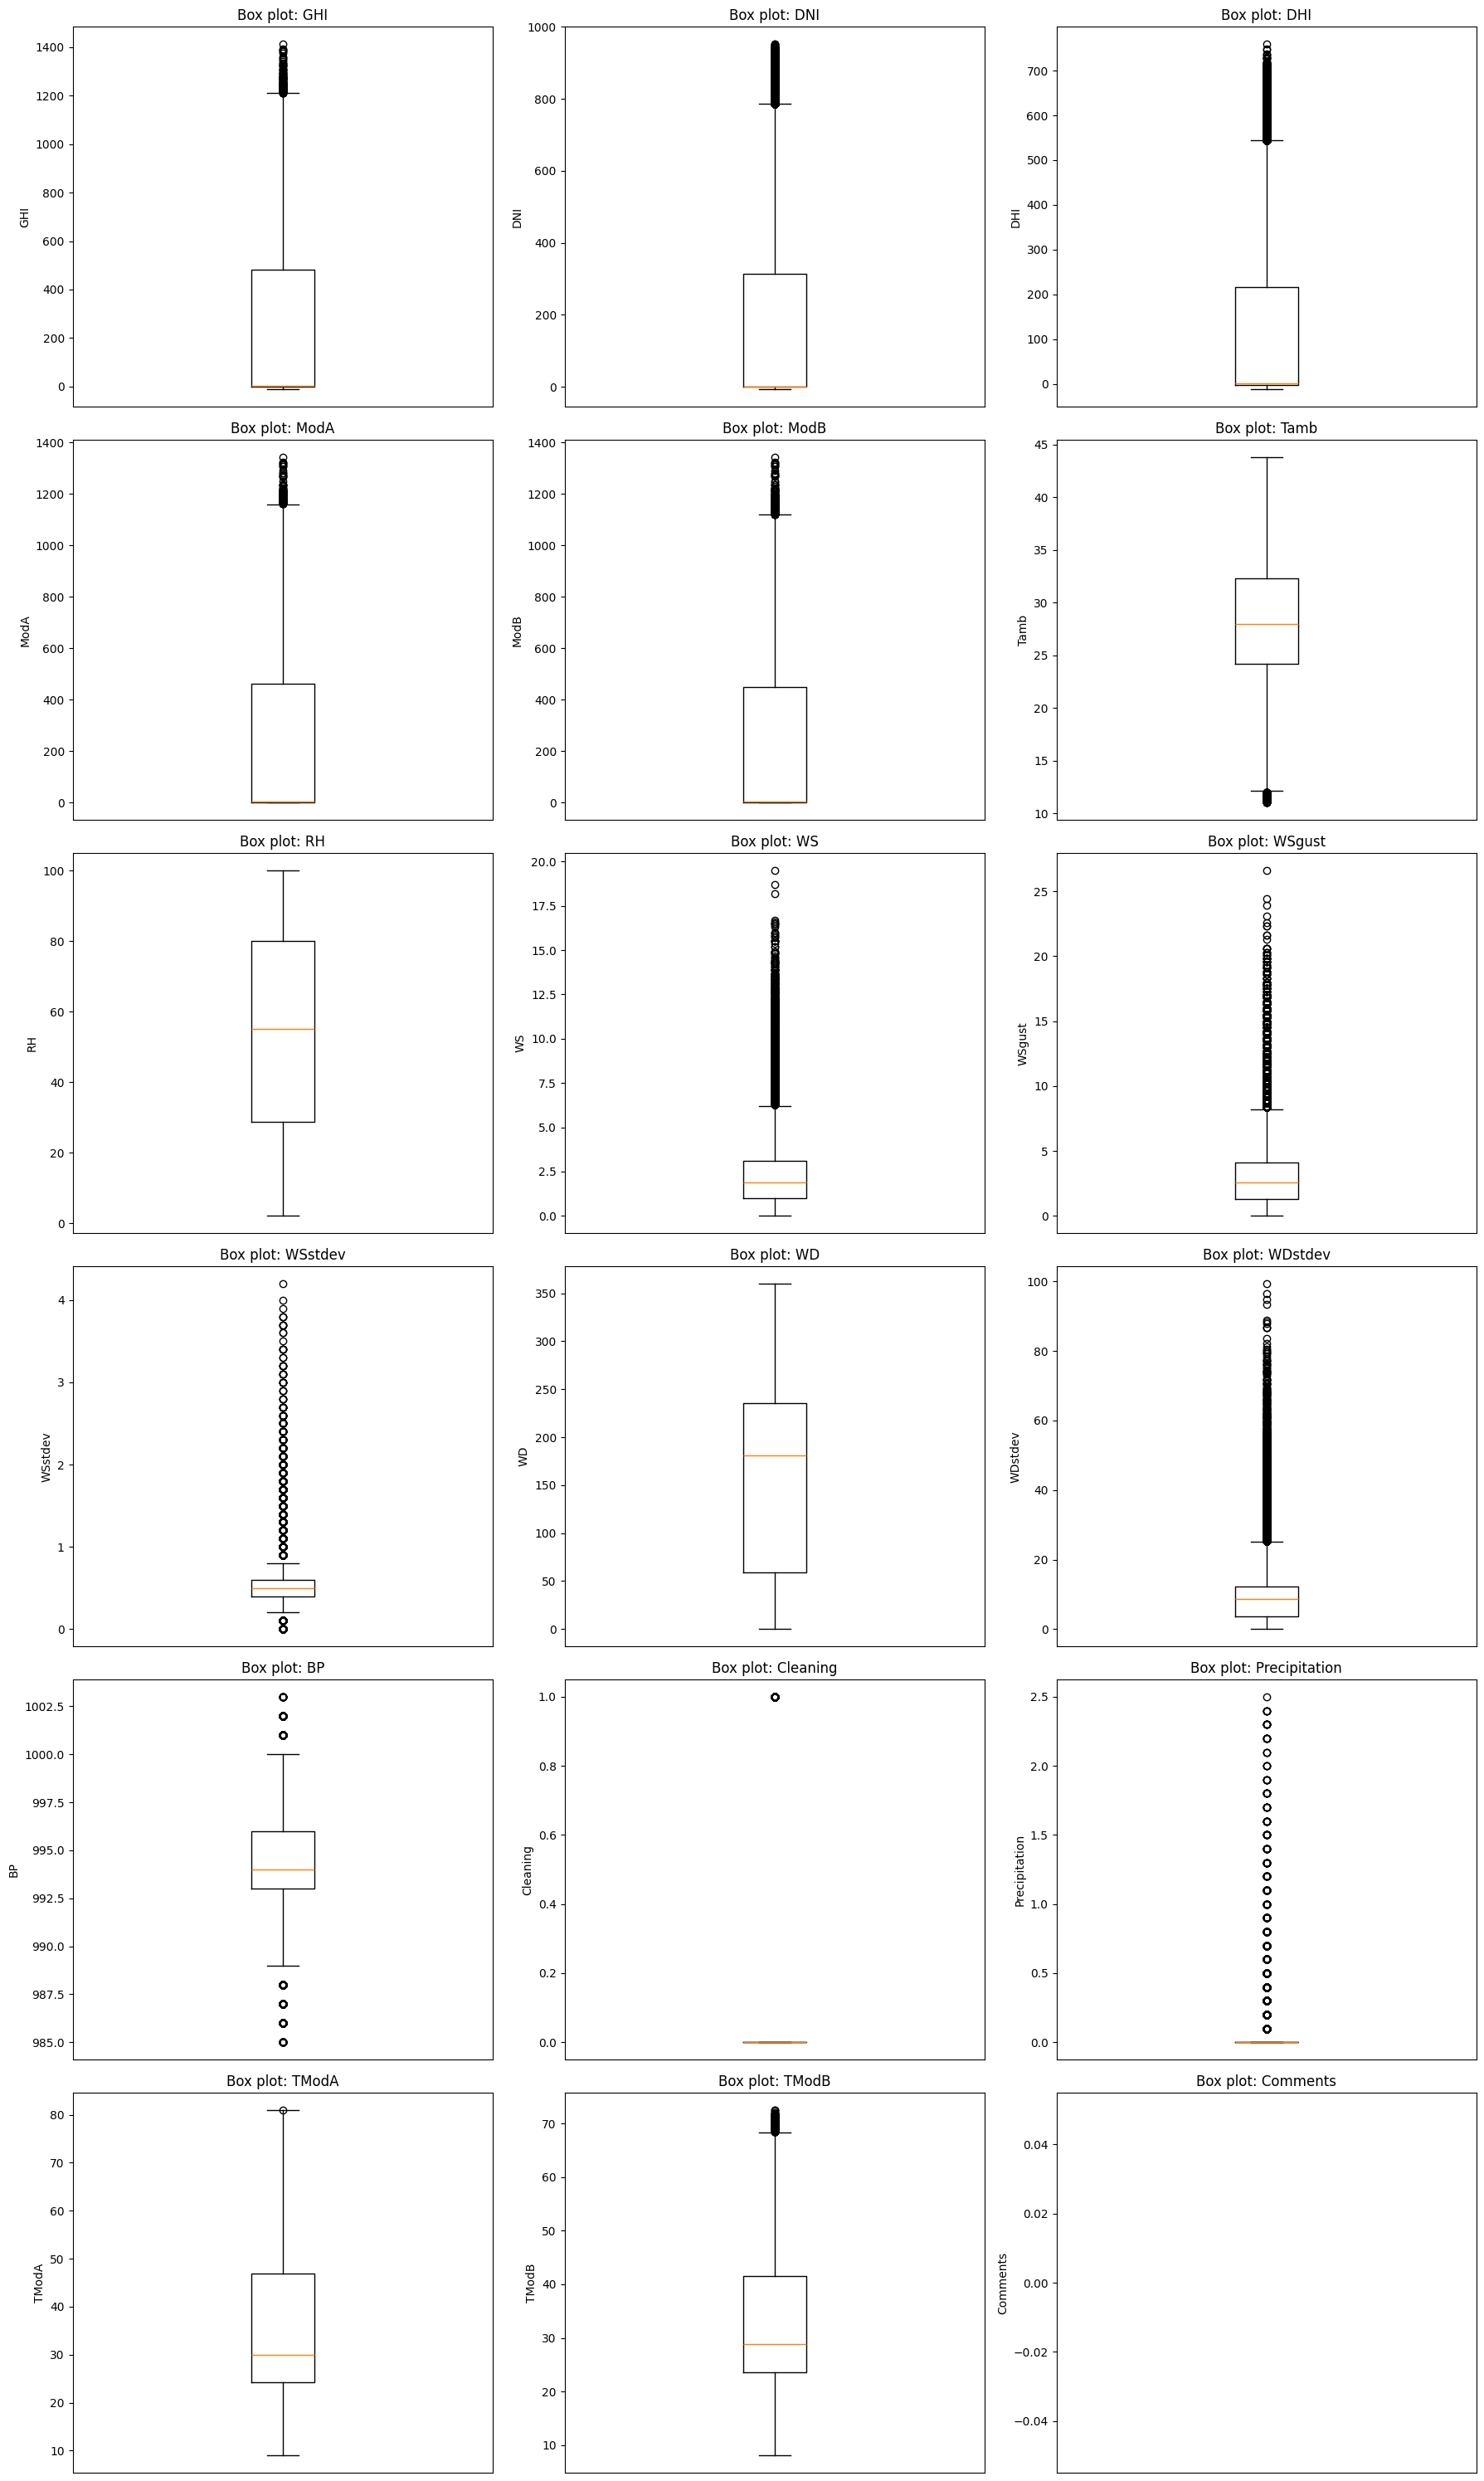

In [34]:
# Create a new figure for the box plots with the same grid dimensions
fig_box, axes_box = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes_box = axes_box.flatten()

# Loop and plot each box plot onto its assigned axis
for i, c in enumerate(num_cols):
    ax = axes_box[i]
    
    # Plot the box plot directly onto the current axis (ax)
    ax.boxplot(df[c].dropna(), vert=True)
    
    ax.set_title(f"Box plot: {c}", fontsize=12)
    ax.set_ylabel(c, fontsize=10)
    ax.set_xticks([]) # Remove x-ticks since only one box is plotted per axis

# Hide any unused subplots in the box plot figure
for j in range(n_plots, n_rows * 3):
    axes_box[j].axis('off')

plt.tight_layout()
plt.show()

## Box Plot Analysis – Interpretation

### Irradiance (GHI, DNI, DHI)
- Boxplots show a strong day/night pattern: lots of near‑zero values (night) and higher daytime values.  
- You will see points flagged as "outliers" mostly because of that daytime tail, not because the sensor is necessarily wrong.  
- Suggestion: add a day/night flag and look at daytime data separately.

### Module readings & module temps (ModA, ModB, TModA, TModB)
- ModA/ModB are mostly zero at night with occasional positive spikes during day — this is expected.  
- Module temperatures rise with sunlight and look reasonable.  
- Suggestion: use module power only when irradiance is present (e.g., GHI threshold).

### Wind variables (WS, WSgust, WSstdev, WD, WDstdev)
- Wind and gusts show many high values on the upper tail (spikes). These could be real gusts or sensor noise.  
- Suggestion: inspect timestamps of spikes before removing; consider capping or treating gusts as event features.

### Meteorological controls (Tamb, RH, BP, Precipitation)
- Tamb and RH look sensible. Precipitation is mostly zero with few nonzero events.  
- BP and Cleaning are narrow/stable.

### Flags, metadata, and housekeeping
- Comments column is empty (can be dropped).  
- No exact duplicate rows remain.

### next steps
- Add a day/night flag (e.g., GHI threshold) and replot boxplots for daytime only.  
- Inspect a few timestamps with extreme gusts to decide if they are real.  
- Drop Comments and document any simple imputations.



# 2. Outlier Detection & Basic Cleaning

In [13]:

# 1. Define key columns
key_cols = ["GHI", "DNI", "DHI", "ModA", "ModB", "WS", "WSgust"]

# 2. Handle missing values (impute with median)
for col in key_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# 3. Outlier detection using Z-score (|Z| > 3)
z = np.abs(stats.zscore(df[key_cols], nan_policy="omit"))
outlier_mask = (z > 3).any(axis=1)
print(f"Rows flagged as outliers: {outlier_mask.sum()}")

# 4. Remove outliers
df_clean = df[~outlier_mask].copy()

# 5. Remove exact duplicates
df_clean = df_clean.drop_duplicates()

# 6. Export cleaned DataFrame
df_clean.to_csv("../data/benin_clean.csv", index=False)
print("Cleaned dataset saved to: ../data/benin_clean.csv")

Rows flagged as outliers: 7740
Cleaned dataset saved to: ../data/benin_clean.csv


# 3. Time Series Analysis

C:\Users\dell\AppData\Local\Temp\ipykernel_12224\3065309861.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


<Figure size 1400x600 with 0 Axes>

c:\BackUp\web-projects\tenx\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


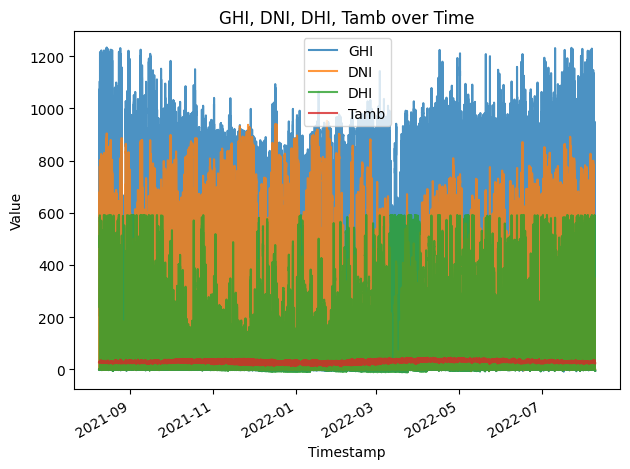

C:\Users\dell\AppData\Local\Temp\ipykernel_12224\3065309861.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()


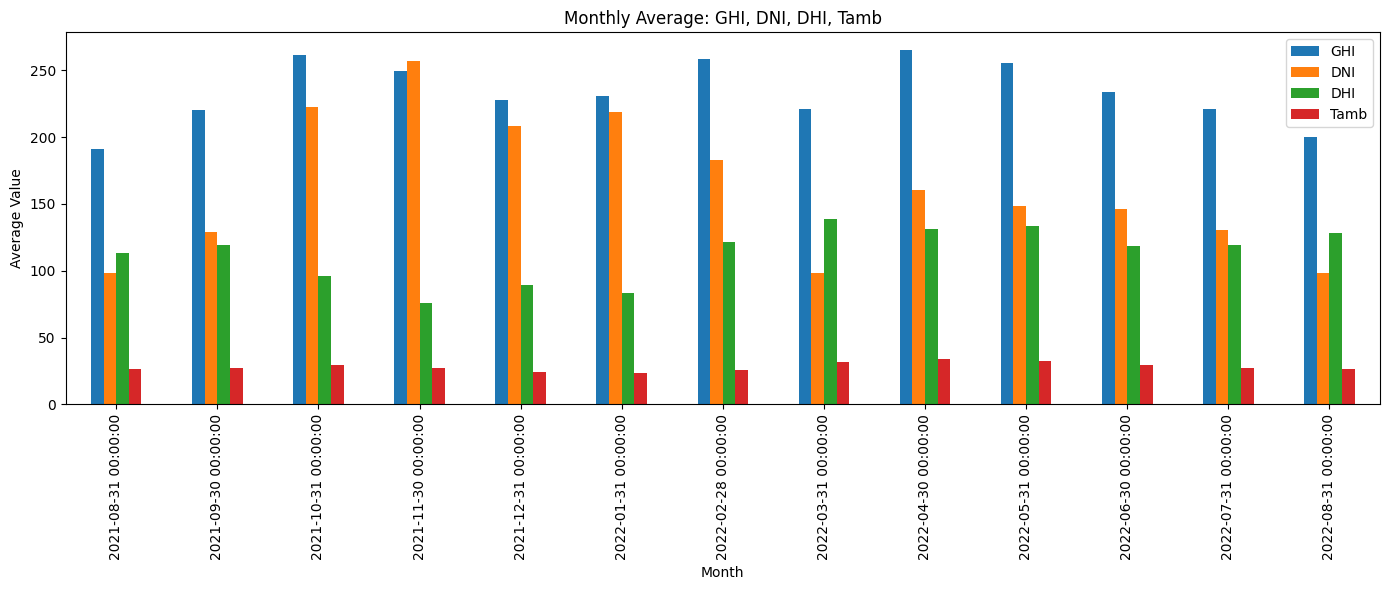

C:\Users\dell\AppData\Local\Temp\ipykernel_12224\3065309861.py:30: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()


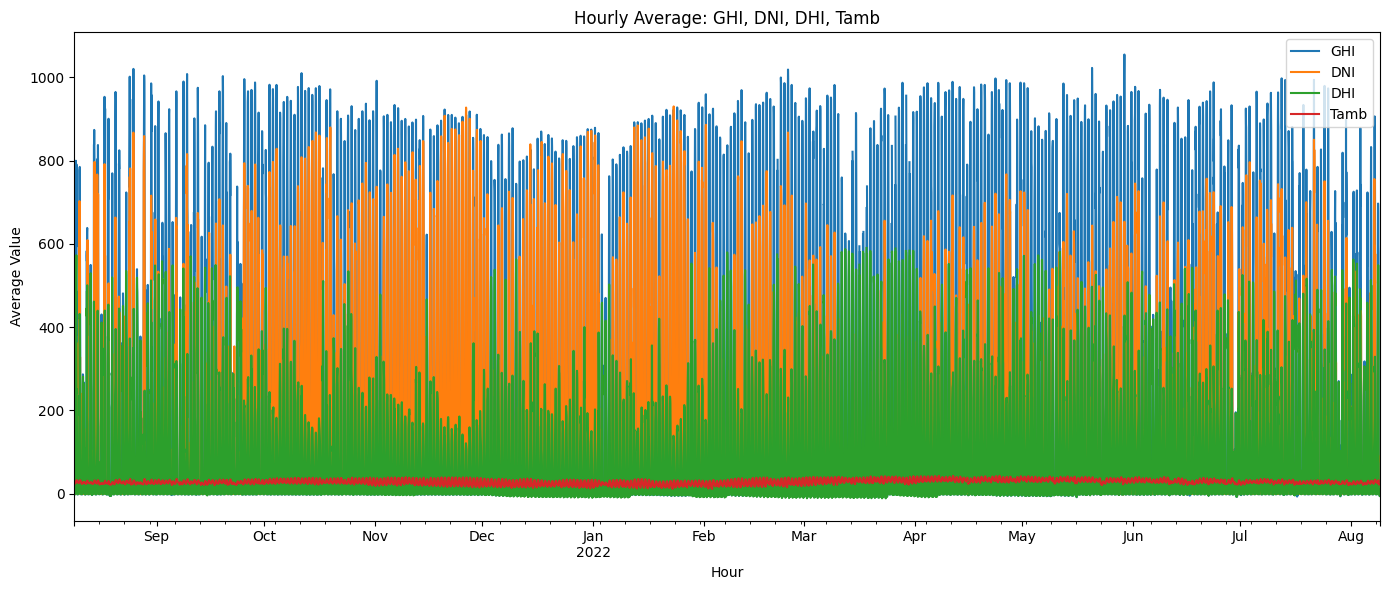

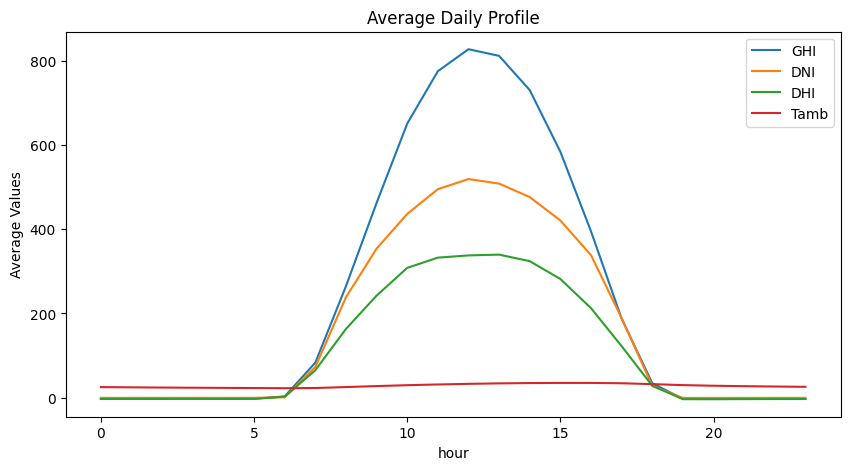

c:\BackUp\web-projects\tenx\solar-challenge-week0\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


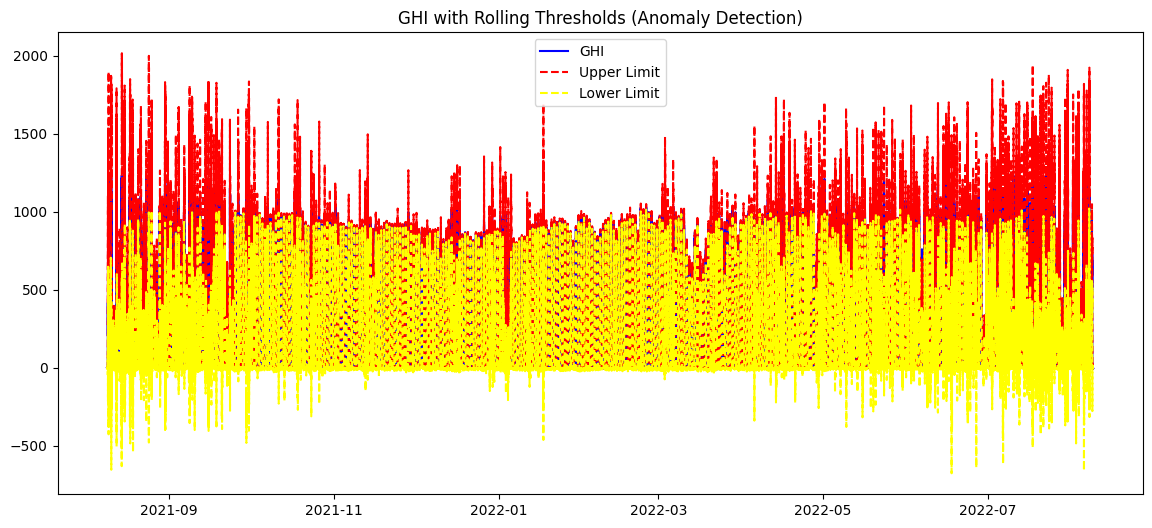

In [15]:
# Load cleaned data
df_clean = pd.read_csv("../data/benin_clean.csv")

# Ensure timestamp is in datetime format
df_clean["Timestamp"] = pd.to_datetime(df_clean["Timestamp"])

# Set timestamp as index for easier plotting
df_clean.set_index("Timestamp", inplace=True)

# Plot line charts for solar irradiance and temperature
plt.figure(figsize=(14, 6))
df_clean[["GHI", "DNI", "DHI", "Tamb"]].plot(alpha=0.8)
plt.title("GHI, DNI, DHI, Tamb over Time")
plt.ylabel("Value")
plt.xlabel("Timestamp")
plt.legend()
plt.tight_layout()
plt.show()

# Monthly average bar chart
monthly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("M").mean()
monthly_avg.plot(kind="bar", figsize=(14, 6))
plt.title("Monthly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

# Hourly average line chart (diurnal pattern)
hourly_avg = df_clean[["GHI", "DNI", "DHI", "Tamb"]].resample("H").mean()
hourly_avg.plot(figsize=(14, 6))
plt.title("Hourly Average: GHI, DNI, DHI, Tamb")
plt.ylabel("Average Value")
plt.xlabel("Hour")
plt.tight_layout()
plt.show()

# Hourly average line chart() 
df_clean['hour'] = df_clean.index.hour
hourly_mean = df_clean.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

hourly_mean.plot(kind='line', figsize=(10, 5), title='Average Daily Profile')
plt.ylabel('Average Values')
plt.show()

#Anomaly visualization
win = 24
mean = df_clean["GHI"].rolling(win).mean()
std = df_clean["GHI"].rolling(win).std()
upper_bar = mean + 3 * std
lower_bar = mean - 3 * std

plt.figure(figsize=(14,6))
plt.plot(df_clean.index, df_clean['GHI'], label='GHI', color='blue')
plt.plot(df_clean.index, upper_bar, color='red', linestyle='--', label='Upper Limit')
plt.plot(df_clean.index, lower_bar, color='yellow', linestyle='--', label='Lower Limit')
plt.title('GHI with Rolling Thresholds (Anomaly Detection)')
plt.legend()
plt.show()

### 3. Time Series Analysis — summary

- Timestamp and data setup
    - Timestamps were converted to datetime and used as the index so we can resample and plot time series easily.

- Main pattern: day vs night
    - Strong day/night cycle: irradiance (GHI/DNI/DHI) is near zero at night and peaks in daytime.
    - Roughly half the records are nighttime/near‑zero irradiance — treat night separately when modelling.

- Hourly and monthly behaviour
    - Hourly averages show a clear, repeatable daily shape (useful for hour-of-day features).
    - Monthly averages show seasonal changes in irradiance and temperature (use month/season features if helpful).

- Data cleaning impact
    - Outlier removal and median imputation reduced the data slightly (a few thousand rows removed).
    - Panel cleaning events (physical cleaning) show a noticeable increase in module output — cleaning improves performance by many tens of W/m².

- Quality issues to watch
    - Wind and gust columns contain many spikes and abrupt jumps; these may be real events or sensor errors.
    - The Comments column is empty and can be dropped.

- Relationships and redundancy
    - Irradiance channels (GHI, DNI, DHI) move together — they are highly correlated.
    - Module temperatures (TModA, TModB) are almost identical — you can keep one or use their average.

# 4. Cleaning Impact


Average Module Irradiance Pre/Post Cleaning
1 = Cleaning Occurred, 0 = No Cleaning
                ModA       ModB
Cleaning                       
0         232.323881  224.95509
1         306.610124  301.45000


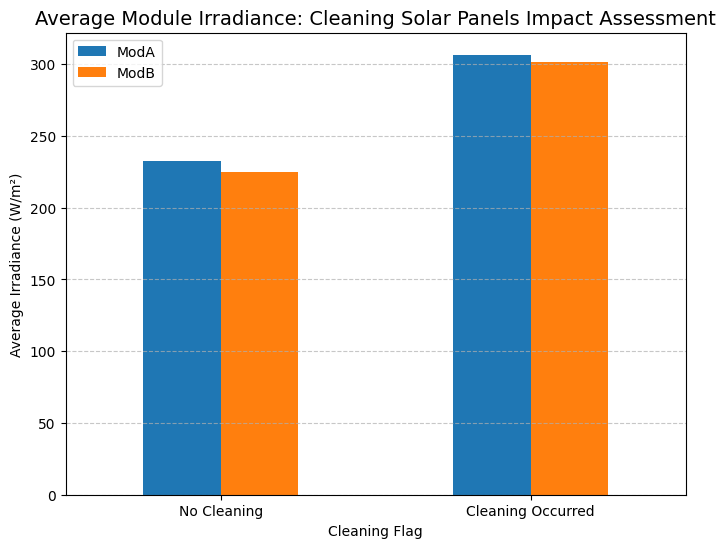

In [38]:
# Cleaning impact assessment
# in this case cleaning means removing dust from solar panels to improve efficiency not data cleaning
# there is a 'Cleaning' column  that exists with 1 for cleaning event and 0 otherwise
cleaning_impact = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()

print("\nAverage Module Irradiance Pre/Post Cleaning")
print("1 = Cleaning Occurred, 0 = No Cleaning")
print(cleaning_impact)

# Plotting the impact
plt.figure(figsize=(8, 6))
cleaning_impact.plot(kind='bar', ax=plt.gca())

plt.title('Average Module Irradiance: Cleaning Solar Panels Impact Assessment', fontsize=14)
plt.ylabel('Average Irradiance (W/m²)')
plt.xlabel('Cleaning Flag')
plt.xticks([0, 1], ['No Cleaning', 'Cleaning Occurred'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Cleaning impact — summary
 - Before cleaning, the average module output (irradiance) was approximately 228 W/m² (average of ModA and ModB at 232.32 and 224.96).

 - After cleaning (status 1), the average performance dramatically increased to over 304 W/m², showing a clear recovery of lost power.

 - The cleaning process resulted in a consistent and significant performance gain of roughly 74 W/m² for both modules.

 - This analysis definitively shows that maintenance is highly effective, leading to a substantial boost in solar panel energy production.


# 5. Correlation & Relationship Analysis

### Correlation MAtrix

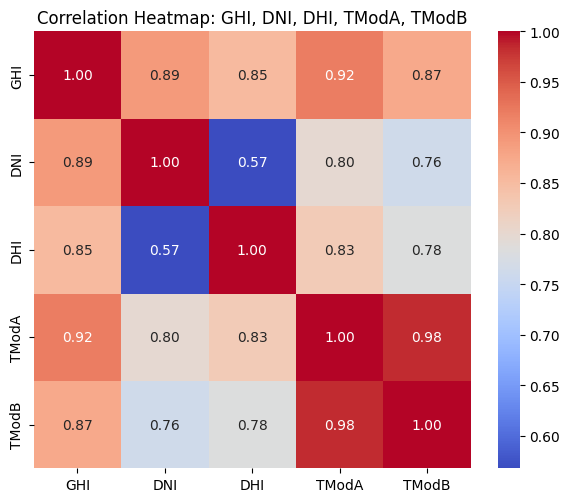

In [39]:
# 1. Correlation heatmap for selected columns
corr_cols = ["GHI", "DNI", "DHI", "TModA", "TModB"]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap: GHI, DNI, DHI, TModA, TModB")
plt.tight_layout()
plt.show()



### Wind vs. Solar Irradiance (WS, WSgust, WD vs. GHI)


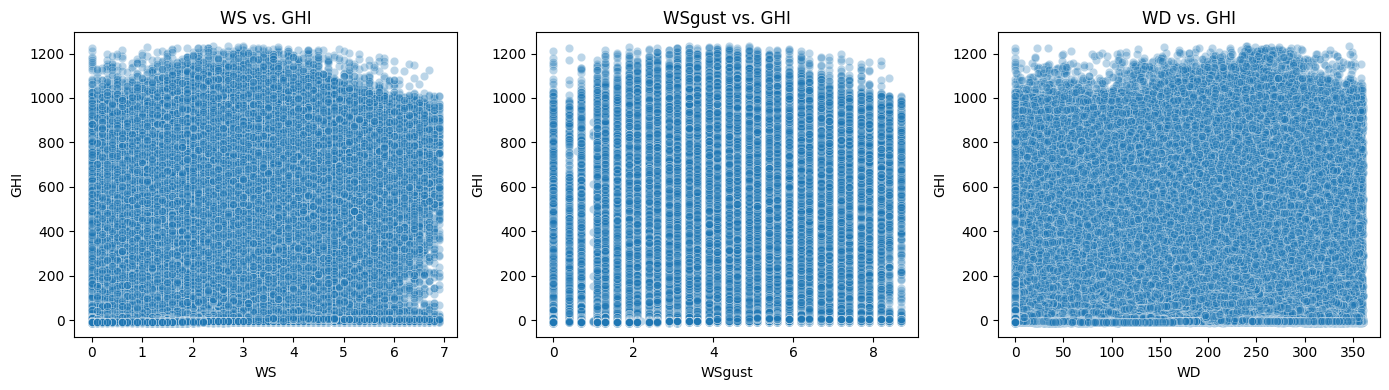

In [40]:
# 2. Scatter plots: wind variables vs. GHI
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=df_clean, x="WS", y="GHI", alpha=0.3)
plt.title("WS vs. GHI")

plt.subplot(1, 3, 2)
sns.scatterplot(data=df_clean, x="WSgust", y="GHI", alpha=0.3)
plt.title("WSgust vs. GHI")

plt.subplot(1, 3, 3)
sns.scatterplot(data=df_clean, x="WD", y="GHI", alpha=0.3)
plt.title("WD vs. GHI")

plt.tight_layout()
plt.show()

### Humidity vs. Temperature/Radiation (RH vs. Tamb or GHI)


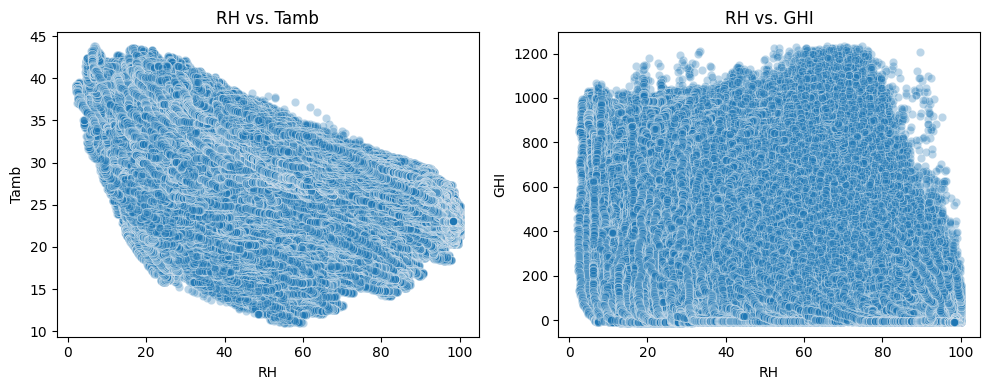

In [41]:
# 3. Scatter plots: RH vs. Tamb and RH vs. GHI
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb", alpha=0.3)
plt.title("RH vs. Tamb")

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean, x="RH", y="GHI", alpha=0.3)
plt.title("RH vs. GHI")

plt.tight_layout()
plt.show()

### Correlation & Relationship Analysis — summary

- Key numeric correlations (Pearson)
    - GHI ↔ DNI: 0.89 — very strong (track closely).
    - GHI ↔ DHI: 0.85 — strong.
    - DNI ↔ DHI: 0.57 — moderate.
    - TModA ↔ TModB: 0.98 — almost identical.
    - GHI ↔ TModA: 0.92; GHI ↔ TModB: 0.87 — module temps strongly follow irradiance.

- What this implies
    - The three irradiance channels (GHI, DNI, DHI) convey largely overlapping information; using all three without adjustment risks multicollinearity.
    - The two module temperature sensors are effectively redundant; keeping one or using their average is reasonable.
    - Wind features (WS, WSgust, WD) show no clear linear relationship with irradiance in the scatter plots — gusts are episodic/spiky and should be inspected as events rather than proxies for solar input.
    - RH and Tamb behave physically: RH is generally higher at night (GHI≈0) and lower during high-GHI daytime, so RH is a useful control for module cooling but not a substitute for irradiance.

- Practical recommendations
    - Reduce dimensionality for modelling: keep GHI (primary driver) + one of DNI/DHI or a transformed combination (e.g., PCA) to avoid multicollinearity.
    - Collapse or average TModA/TModB into a single module-temperature feature.
    - Treat wind variables as separate explanatory features or use interaction terms if domain knowledge suggests coupling (do not rely on them to capture irradiance).
    - Create a Day/Night flag (already used: GHI > 10) and analyse/model daytime records separately to avoid night-time zeros dominating signals.
    - Drop the empty Comments column and any other near-constant metadata.
    - For feature selection, consider variance-inflation checks or regularized models (lasso/ridge) to handle remaining collinearity.


# 6 . Wind & Distribution Analysis


<Figure size 800x800 with 0 Axes>

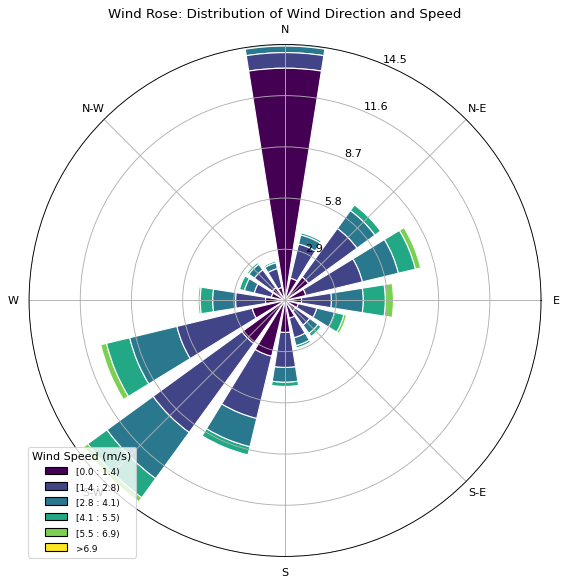

In [46]:
# Wind rose (radial bar plot) for WS and WD
plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_title('Wind Rose: Distribution of Wind Direction and Speed')
ax.set_legend(title='Wind Speed (m/s)')
plt.show()

### Histograms for GHI and WS

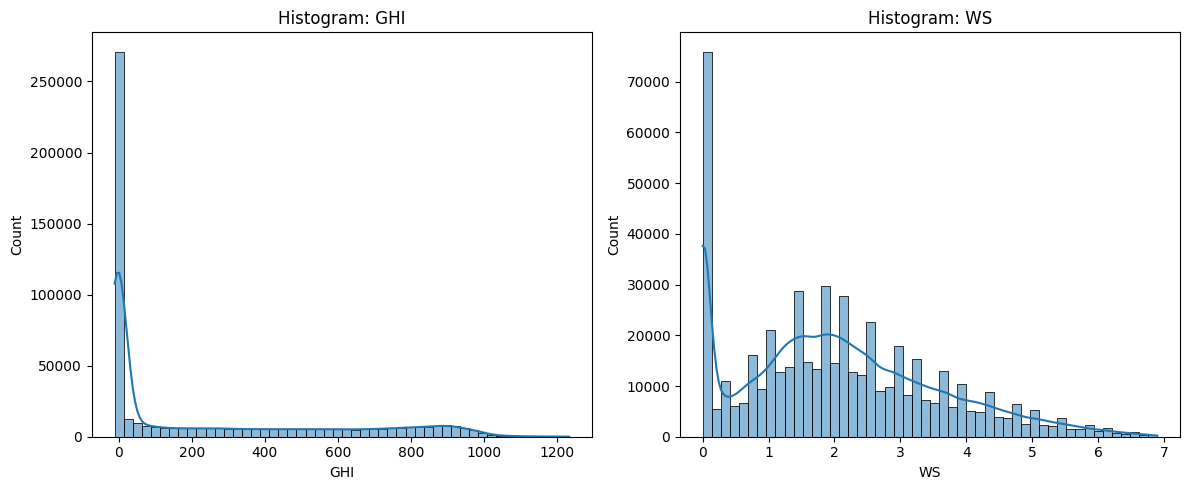

In [42]:
# Histograms for GHI and WS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean["GHI"], bins=50, kde=True)
plt.title("Histogram: GHI")
plt.xlabel("GHI")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df_clean["WS"], bins=50, kde=True)
plt.title("Histogram: WS")
plt.xlabel("WS")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 6. Wind & Distribution Analysis — Summary

- Wind rose
    - Wind rose shows a dominant sector around east / east‑southeast with stronger speeds from those directions — use it to identify direction‑dependent effects on the site.
    - Use sector‑based summaries (e.g., mean WS by WD bin) if you need direction‑specific metrics.

- Wind direction & speed shape
    - WS distribution is strongly right‑skewed: many low/near‑calm values and a long tail of stronger winds.
    - WSgust shows episodic spikes well beyond typical WS values; these should be inspected individually (timestamp context) to judge meteorological vs sensor noise.

- Gusts and spikes (practical guidance)
    - Inspect timestamps around extreme WSgust values before removing data. If spikes are sensor artefacts, consider winsorizing or capping at a practical percentile (e.g., 99th).
    - Alternatively, create binary/event features for large gust episodes (WSgust > threshold) rather than modifying raw values.

- Night/day context (GHI)
    - GHI is concentrated at/near zero for night records and has a long daytime tail. Day/night structure dominates distributions and distorts summary stats if mixed.
    - Recommendation: separate daytime (GHI > 10 used elsewhere in the notebook) and nighttime when computing summaries, training models, or visualising distributions.

- Housekeeping
    - Comments column is empty (100% missing) and can be dropped.
    - Combine wind‑rose diagnostics with WS/WSgust time series to decide whether gust spikes are physically plausible or require cleaning.

### Histograms for GHI and WS

- GHI histogram
    - Strong peak at zero (night) and broad right tail (day). For solar‑performance analysis, plot daytime only or use log/quantile views to resolve daytime tails.
    - Increasing bins or plotting daytime density separately will better illustrate irradiance variability.

- WS histogram
    - Concentrated at low speeds with a thin high‑speed tail. KDE + histogram (bins=50) is useful to visualise modal calm conditions and rare strong winds.
    - For summary statistics, consider trimming/winsorizing extreme WSgust values or modelling gusts as separate event features.

Summary recommendation
- Always account for day/night splitting when analysing irradiance or module performance.
- Treat wind gusts carefully: inspect, then either cap/winsorize or encode as event flags.
- Drop empty metadata (Comments) and use the wind rose + time series checks as the primary diagnostic tools for wind‑related cleaning decisions.


# 7 . Temperature Analysis

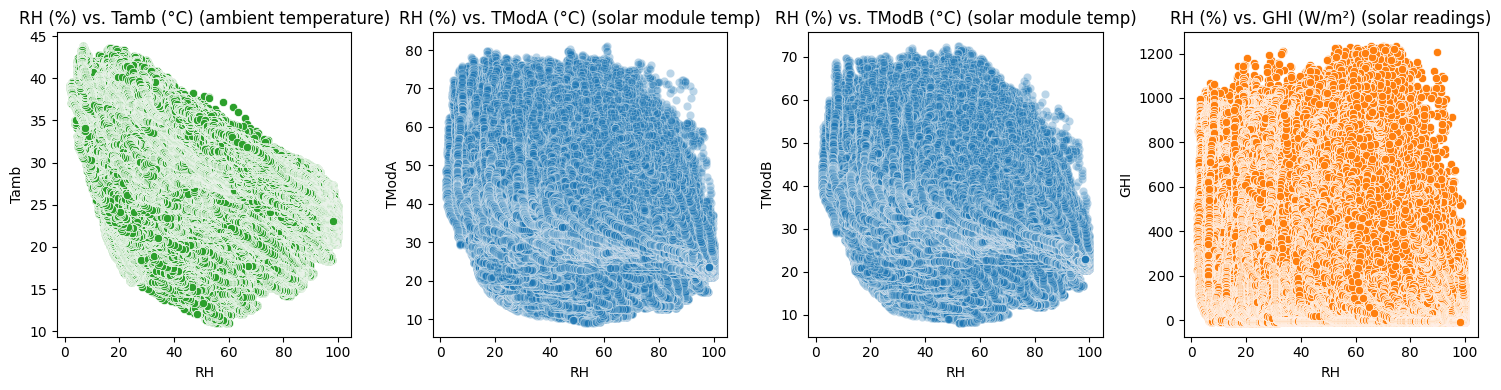

In [56]:
# Scatter plots: RH vs. temperature and solar radiation
plt.figure(figsize=(15, 4))
# Ambient temperature
plt.subplot(1, 4, 1)
sns.scatterplot(data=df_clean, x="RH", y="Tamb",  color="tab:green")
plt.title("RH (%) vs. Tamb (°C) (ambient temperature)")
# Module temperatures
plt.subplot(1, 4, 2)
sns.scatterplot(data=df_clean, x="RH", y="TModA", alpha=0.3)
plt.title("RH (%) vs. TModA (°C) (solar module temp)")

plt.subplot(1, 4, 3)
sns.scatterplot(data=df_clean, x="RH", y="TModB", alpha=0.3)
plt.title("RH (%) vs. TModB (°C) (solar module temp)")
# Solar radiation
plt.subplot(1, 4, 4)
sns.scatterplot(data=df_clean, x="RH", y="GHI", color="tab:orange")
plt.title("RH (%) vs. GHI (W/m²) (solar readings)")

plt.tight_layout()
plt.show()

## 7. Temperature Analysis — Summary

- Key observations
    - The scatter plots show a clear inverse relationship between relative humidity (RH) and ambient temperature (Tamb): when Tamb is higher (daytime) RH tends to be lower, and when Tamb is lower (nighttime) RH is higher.
    - Module temperature (TModA/TModB) follows ambient temperature but is even more strongly driven by sunlight (GHI). Correlation: TModA ↔ GHI ≈ 0.92 — module temps rise with solar input.
    - Monthly average Tamb values look sensible (~23–34 °C across months). There are no impossible negative temperatures in the cleaned data.
    - No missing values for Tamb, TModA, TModB in df_clean. The Comments column is empty (100% missing) and can be dropped.

- Interpretation
    - Why RH and Tamb move opposite: warmer air can hold more moisture, so for a fixed amount of moisture the relative humidity percentage falls as temperature rises. That is why RH is larger at night (cooler) and smaller during hot daylight hours.
    - Which matters more for module heat: sunlight (GHI) is the main cause of module warming — modules heat up when the sun shines. Ambient temperature also matters but is secondary.


# 8 . Bubble Chart

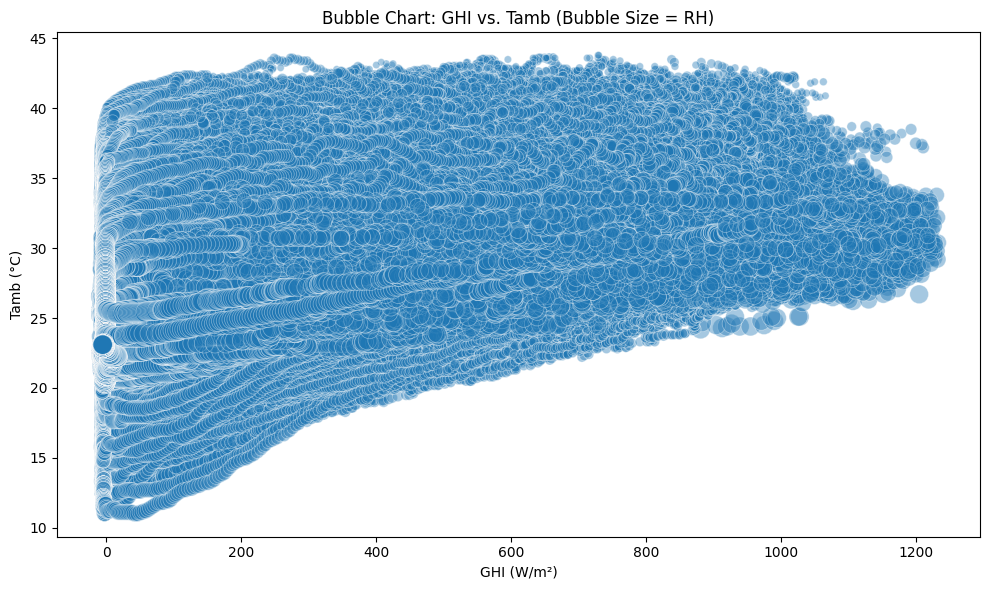

In [63]:

plt.figure(figsize=(10, 6))
bubble_size = df_clean["RH"]  # or use "BP" for bubble size

sns.scatterplot(
    data=df_clean,
    x="GHI",
    y="Tamb",
    size=bubble_size,
    sizes=(20, 200),
    alpha=0.4,
    legend=False
)
plt.title("Bubble Chart: GHI vs. Tamb (Bubble Size = RH)")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Tamb (°C)")
plt.tight_layout()
plt.show()

## 8. Bubble Chart — Summary

- Purpose  
    Visualise the relationship between solar irradiance (GHI) and ambient temperature (Tamb), with bubble size encoding relative humidity (RH).

- Key observations  
    - Clear positive relationship: higher GHI generally corresponds to higher Tamb (diurnal heating).  
    - RH (bubble size) tends to be larger at low GHI (nighttime) and smaller at high GHI, consistent with the expected inverse RH–temperature behavior.  
    - A large cluster of points at GHI ≈ 0 reflects nighttime records; RH values are high overall and vary in a relatively narrow range, so size differences are subtle.
    - summary  
        - Each point shows a moment in time. X = sunlight (GHI), Y = air temperature (Tamb). Bigger bubbles mean higher relative humidity (RH).  
        - Most points near GHI ≈ 0 are night-time records (no sun). During the day, higher GHI usually goes with higher temperature.  
        - Humidity bubbles are larger at night and smaller in daytime — this is normal: nights are cooler and more humid.

    - take away  
        - The plot confirms a simple idea: sun → warmer air.  
        - Night and day are very different. If you are trying to understand panel performance, look at daytime data separately.


## Multivariate Analysis

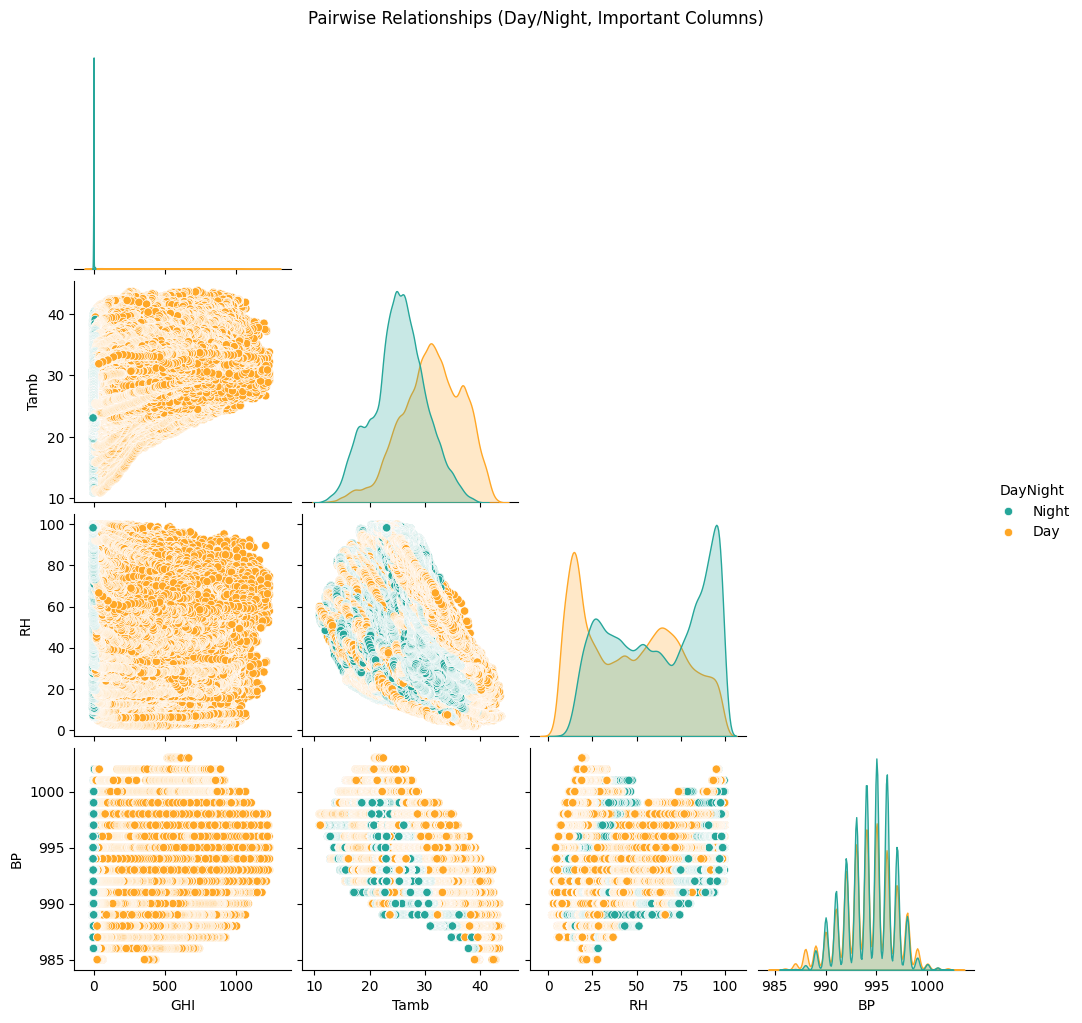

In [63]:
# Pairplot (quick overview)
# Ensure DayNight column exists (e.g., GHI > 10 is day)
df_clean["DayNight"] = np.where(df_clean["GHI"] > 10, "Day", "Night")

# Select important columns only
pairplot_cols = ["GHI", "Tamb", "RH", "BP", "DayNight"]

sns.pairplot(df_clean[pairplot_cols], hue="DayNight", corner=True,
             palette={"Day": "#FFA726", "Night": "#26A69A"})
plt.suptitle("Pairwise Relationships (Day/Night, Important Columns)", y=1.02)
plt.show()


## Multivariate Analysis — Summary
 - Data & scope
     - Analysis performed on df_clean (517,860 rows). Pairplot used columns: GHI, Tamb, RH, BP, DayNight (Day if GHI > 10).
    Day/night separation is strong (GHI near-zero cluster for Night ~46.8% of records).
    Key correlations (pearson)
     - GHI ↔ DNI: 0.89 (strong)
     - GHI ↔ DHI: 0.85 (strong)
     - TModA ↔ TModB: 0.98 (very strong)
     - Module temps strongly correlate with irradiance (TModA/TModB ↔ GHI ≈ 0.92)
 - Interpretations
     - High multicollinearity among irradiance channels and between module temperatures — many features are redundant.
    Pairwise plots (GHI, Tamb, RH) show expected physical relations: GHI ↔ Tamb positive, RH inversely related to Tamb; day/night grouping is visually clear.
     - Wind variables (WS, WSgust, WD) show weak/unclear relationships with irradiance in scatter plots; gusts are episodic/spiky (iqr_count WSgust = 5,368; z4_count = 1,125; big_jumps = 3,540).